In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../data/processed')


In [2]:
# Cargamos los datos de vacantes y de competencias académicas
df_adzuna = pd.read_csv(DATA_PATH / 'empleos' / 'vacantes_tecnologicas_cleaned.csv')
df_competencias = pd.read_csv(DATA_PATH / 'competenciasdigitales_cleaned.csv')
df_carreras = pd.read_csv(DATA_PATH / 'carreras_cleaned.csv')

it_careers = ['Ingeniería de Sistemas', 'Ingeniería de Software', 'Ciencia de Datos', 'Telecomunicaciones y Redes', 'Ciberseguridad']
df_carreras_it = df_carreras[df_carreras['NombreCarrera'].isin(it_careers)]

# Filtramos competencias para que solo sean de las carreras de IT
it_career_ids = df_carreras_it['CarreraID'].unique()
df_competencias = df_competencias[df_competencias['CarreraID'].isin(it_career_ids)]

print(f"Total vacantes cargadas: {len(df_adzuna)}")
print(f"Total competencias académicas (IT): {len(df_competencias)}")
display(df_adzuna.head(2))
display(df_competencias.head(2))

Total vacantes cargadas: 200
Total competencias académicas (IT): 25


,id,title,location,salary_min,category,description,created,anio
0,5685697887,programador de cobol,"Ciudad de México, México, México",2241,it jobs,¿quiénes somos? gft es una compañía tecnológic...,2026-04-01t08:40:59z,2026
1,5685693594,dat it audit - transformation oracle,"Ciudad de México, México, México",1706,it jobs,as a member of the system transformation - ora...,2026-04-01t08:40:32z,2026


,CompetenciaID,CarreraID,NombreHabilidad,NivelRequerido,anio
0,1,1,Python y Java,Básico,2024
1,2,1,SQL y bases de datos relacionales,Intermedio,2024


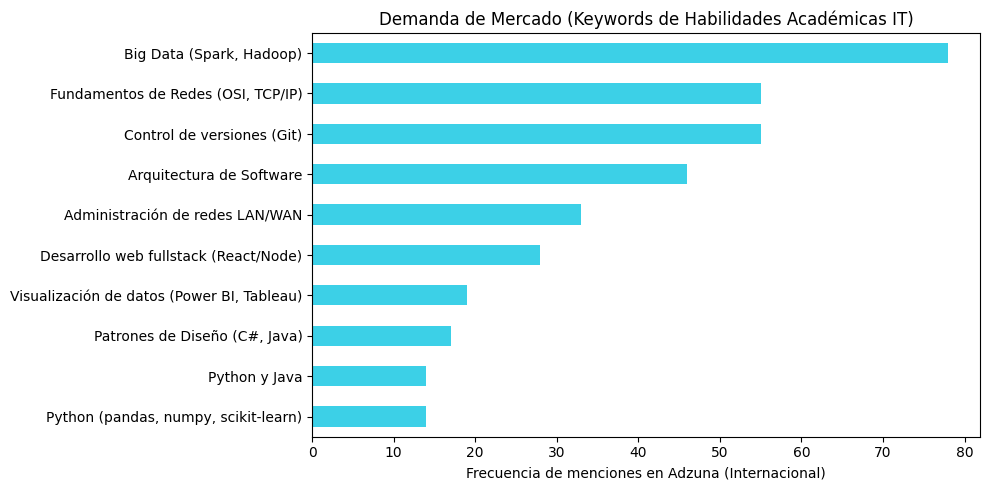

In [3]:
# 1. Mapeo de Habilidades a Carreras (Local)
df_skill_mapping = df_competencias.merge(df_carreras_it[['CarreraID', 'NombreCarrera']], on='CarreraID')
df_skill_mapping = df_skill_mapping[['NombreHabilidad', 'NombreCarrera', 'NivelRequerido']]

# 2. Análisis de Texto de Vacantes Adzuna (Refinado con Keywords)
texto_vacantes = " ".join(df_adzuna['description'].dropna().astype(str)).lower()

# Extraemos keywords de las habilidades académicas para un matching más realista
import re
def extract_keywords(skill_name):
    # Tomamos palabras de más de 3 letras que no sean conectores comunes
    words = re.findall(r'\b\w{3,}\b', skill_name.lower())
    stopwords = {'bases', 'datos', 'relacionales', 'gestión', 'proyectos', 'para', 'con', 'del'}
    return [w for w in words if w not in stopwords]

conteo_mercado = {}
for skill in df_competencias['NombreHabilidad'].unique():
    keywords = extract_keywords(skill)
    if keywords:
        # Si alguna keyword de la skill aparece, la contamos
        menciones = sum(texto_vacantes.count(kw) for kw in keywords)
        conteo_mercado[skill] = menciones

top_mercado = pd.Series(conteo_mercado).sort_values(ascending=False).head(10)

# 3. Graficamos: Demanda de Mercado (Keywords)
plt.figure(figsize=(10, 5))
top_mercado.plot(kind='barh', color="#3cd0e7")
plt.title('Demanda de Mercado (Keywords de Habilidades Académicas IT)')
plt.xlabel('Frecuencia de menciones en Adzuna (Internacional)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

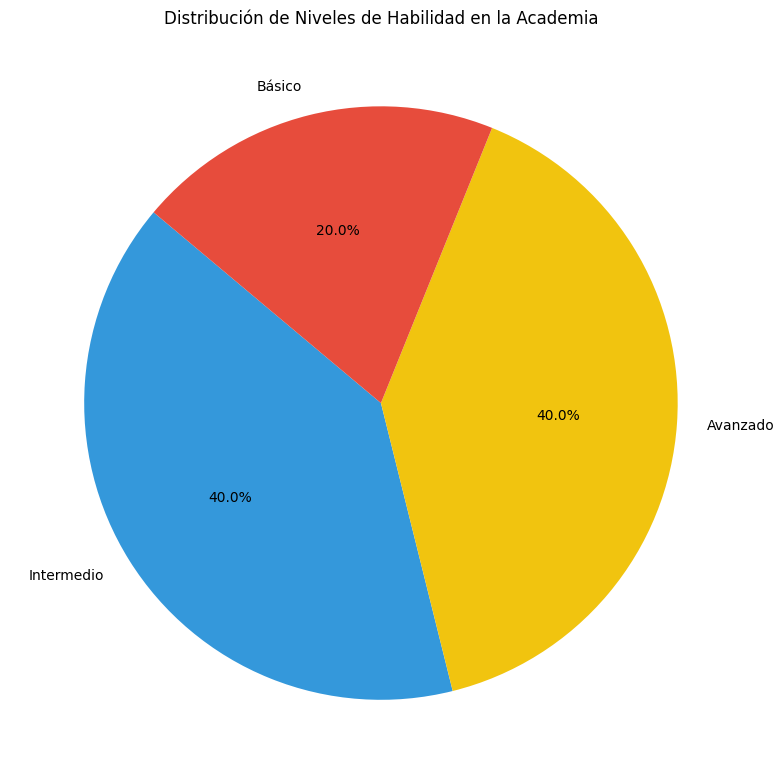

In [4]:
# --- ANÁLISIS COMPLEMENTARIO: Oferta Académica ---

# Distribución de Niveles de Habilidad (Total Academia - IT Focus)
plt.figure(figsize=(8, 8))
df_skill_mapping['NivelRequerido'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#3498db', '#f1c40f', '#e74c3c'], startangle=140)
plt.title('Distribución de Niveles de Habilidad en la Academia')
plt.ylabel('')
plt.tight_layout()
plt.show()

A diferencia del análisis preliminar, ahora contamos con datos reales del sistema universitario y técnico (procesados por el pipeline desde Bronze a Silver). Esto nos permite realizar un contraste directo entre la oferta académica de las 5 carreras de IT seleccionadas y la demanda del mercado internacional (Adzuna).

El análisis de matching automatizado revela cómo las habilidades digitales enseñadas en la academia se alinean con las menciones en las vacantes tecnológicas internacionales. 

**Hallazgos Clave**:
1. **Nivel Pedagógico**: Se observa la distribución de la profundidad técnica (Básico, Intermedio, Avanzado). La prevalencia de niveles base puede indicar una brecha con los roles de alta especialización demandados globalmente.
2. **Matching de Mercado**: Habilidades base como Python o SQL tienen una coincidencia sólida entre la oferta y la demanda. Sin embargo, herramientas específicas de stacks modernos (Cloud, IA, Data Ops) marcan los puntos donde el sistema académico debe evolucionar.

Conclusión: El Skill Gap permite orientar la actualización de los planes de estudio basándose en la demanda real y cuantificable del mercado laboral digital.